<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/Pilot_Normalize%2BRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_df.csv to test_df.csv
Saving train_df.csv to train_df.csv
Saving val_df.csv to val_df.csv


In [ ]:
train_df = pd.read_csv('train_df.csv')
test_df = pd.read_csv('test_df.csv')
val_df = pd.read_csv('val_df.csv')
train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds
0,1,1,1,-0.014656,0.68,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0
1,1,1,1,0.996618,1.45,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0
2,1,1,1,1.978579,3.75,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0
3,1,1,1,2.989853,7.77,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0
4,1,1,1,3.986471,12.52,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0


In [ ]:
test_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds
count,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000
mean,3.398230,1.345133,5.194690,7.148561,10.623501,366.148230,223.495575,21.275664,0.018363,22.663717,0.861159,1.984956,160234.391504
std,0.491714,0.678363,1.475142,4.394641,6.746859,665.063745,153.487850,10.950683,0.016326,29.176018,0.353566,0.093752,254917.990474
min,3.000000,1.000000,4.000000,-0.060700,0.630000,0.250000,40.000000,8.000000,0.000000,2.600000,0.408000,1.900000,4794.770000
25%,3.000000,1.000000,4.000000,2.998400,4.189944,0.250000,77.000000,13.380000,0.004000,2.600000,0.681000,1.900000,7991.280000
50%,3.000000,1.000000,4.000000,7.008900,11.410000,5.000000,200.000000,18.700000,0.010000,7.000000,0.838000,2.000000,29957.820000
75%,4.000000,1.000000,7.000000,11.052100,15.083799,500.000000,300.000000,31.860000,0.040000,40.700000,0.960000,2.000000,301231.010000
max,4.000000,3.000000,7.000000,14.094200,24.972067,2000.000000,500.000000,36.900000,0.040000,89.760000,1.640000,2.200000,762006.050000


In [ ]:
val_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds
count,93.0,93.0,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,4.0,1.0,6.677419,6.754836,7.423209,827.688172,130.526882,27.887527,0.006323,40.448602,1.433441,1.806452,223189.142258
std,0.0,0.0,1.497544,4.306419,4.009932,853.502553,84.652434,9.075396,0.004179,28.537682,0.458847,0.206317,136604.589588
min,4.0,1.0,5.000000,0.000000,0.502793,3.000000,30.000000,13.380000,0.000000,6.980000,0.950000,1.500000,29957.820000
25%,4.0,1.0,5.000000,3.031800,4.860335,3.000000,77.000000,13.380000,0.000000,6.980000,0.950000,1.500000,29957.820000
50%,4.0,1.0,8.000000,6.866200,8.212291,500.000000,99.000000,31.860000,0.008000,40.670000,1.620000,1.900000,264925.600000
75%,4.0,1.0,8.000000,10.879000,10.558659,2000.000000,260.000000,32.980000,0.010000,61.110000,1.640000,2.000000,301231.010000
max,4.0,1.0,8.000000,14.000000,14.791667,2000.000000,260.000000,38.230000,0.010000,89.760000,2.170000,2.000000,410191.000000


In [ ]:
train_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds
count,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000,393.000000
mean,3.302799,1.137405,5.770992,6.713013,10.326809,235.663308,229.613232,36.990127,0.017008,14.556005,0.925069,1.906921,75364.237455
std,1.440102,0.430295,4.195901,4.142156,6.877854,518.747503,213.368030,43.555819,0.014841,14.447148,0.403316,0.235124,99385.618471
min,1.000000,1.000000,1.000000,-0.014656,0.290000,0.015000,30.000000,8.000000,0.000000,1.100000,0.408000,1.440000,3638.000000
25%,2.000000,1.000000,2.000000,3.000000,4.550000,2.000000,121.000000,16.300000,0.010000,5.400000,0.570000,1.800000,13825.000000
50%,3.000000,1.000000,3.000000,6.990981,9.400000,5.000000,162.000000,18.900000,0.010000,7.000000,0.838000,1.900000,29957.820000
75%,5.000000,1.000000,10.000000,10.007992,15.320000,200.000000,260.000000,33.000000,0.020000,20.320000,1.252000,2.080000,79728.000000
max,5.000000,3.000000,12.000000,14.045802,27.272727,2000.000000,1050.000000,190.000000,0.070000,61.110000,1.930000,2.500000,407807.000000


I will need to group all separate runs for padding.

In [ ]:
train_df['clone_id_group'] = train_df['clone_id']
val_df['clone_id_group'] = val_df['clone_id']
test_df['clone_id_group'] = test_df['clone_id']

In [ ]:
train_df['volume_group'] = train_df['volume']
val_df['volume_group'] = val_df['volume']
test_df['volume_group'] = test_df['volume']

In [ ]:
train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds,clone_id_group,volume_group
0,1,1,1,-0.014656,0.68,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,1,10.0
1,1,1,1,0.996618,1.45,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,1,10.0
2,1,1,1,1.978579,3.75,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,1,10.0
3,1,1,1,2.989853,7.77,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,1,10.0
4,1,1,1,3.986471,12.52,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,1,10.0


***Normalization***

Normalizing inputs to the range of [-1, 1] (recommended when using RNNs with tanh activation)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
num_cols = ['time', 'vcd', 'volume', 'agitation', 'p_v', 'vvm', 'impeller_d', 'tip_speed', 'aspect_r', 'reynolds']
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train_df[num_cols])

MinMaxScaler(feature_range=(-1, 1))

In [ ]:
train_df[num_cols] = scaler.transform(train_df[num_cols])
val_df[num_cols] = scaler.transform(val_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [ ]:
import joblib
joblib.dump(scaler, 'scaler_pilot.pkl')
files.download('scaler_pilot.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds,clone_id_group,volume_group
0,1,1,1,-1.000000,-0.971093,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
1,1,1,1,-0.856153,-0.914019,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
2,1,1,1,-0.716476,-0.743540,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
3,1,1,1,-0.572630,-0.445571,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
4,1,1,1,-0.430868,-0.093494,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0


**Encoding** fo categorical variables

I use unknown_value=-1so that unknown clones are  represented by -1. Padding = -2 as normalization between -1 and 1.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(train_df[['clone_id']])

for df in [train_df, val_df, test_df]:
    df['clone_id'] = enc.transform(df[['clone_id']])
    df['clone_id'] = df['clone_id'].astype(int)


In [ ]:
train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds,clone_id_group,volume_group
0,1,1,0,-1.000000,-0.971093,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
1,1,1,0,-0.856153,-0.914019,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
2,1,1,0,-0.716476,-0.743540,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
3,1,1,0,-0.572630,-0.445571,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0
4,1,1,0,-0.430868,-0.093494,-0.990015,-0.776471,0.010989,1.0,-0.583403,-0.182654,-0.886792,-0.798342,1,10.0


In [ ]:
val_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds,clone_id_group,volume_group
0,4,1,-1,-0.997915,-0.984227,-0.997015,-0.54902,-0.940879,-1.0,-0.804033,-0.287779,0.056604,-0.869758,5,3.0
1,4,1,-1,-0.855672,-0.934537,-0.997015,-0.54902,-0.940879,-1.0,-0.804033,-0.287779,0.056604,-0.869758,5,3.0
2,4,1,-1,-0.733750,-0.897269,-0.997015,-0.54902,-0.940879,-1.0,-0.804033,-0.287779,0.056604,-0.869758,5,3.0
3,4,1,-1,-0.571187,-0.710930,-0.997015,-0.54902,-0.940879,-1.0,-0.804033,-0.287779,0.056604,-0.869758,5,3.0
4,4,1,-1,-0.449264,-0.574282,-0.997015,-0.54902,-0.940879,-1.0,-0.804033,-0.287779,0.056604,-0.869758,5,3.0


**Time Series**

Group by process ID, clone ID, and volume to correctly separate the time series by scale

In [ ]:
lengths = train_df.groupby(['p_id', 'clone_id_group', 'volume_group', 'r_id']).size().reset_index(name='count')
print(lengths)

    p_id  clone_id_group  volume_group  r_id  count
0      1               1        10.000     1     14
1      1               1        50.000     1     14
2      1               1       200.000     1     14
3      1               1      1000.000     1     14
4      2               2         0.015     1     12
5      2               2         0.250     1     13
6      2               2         5.000     1     13
7      2               2        50.000     1     13
8      2               2       200.000     1     13
9      2               2      2000.000     1     13
10     3               3         0.250     1     13
11     3               3         0.250     2     13
12     3               3         0.250     3     13
13     3               3         5.000     1     15
14     3               3       250.000     1     18
15     4               6         3.000     1     13
16     4               6       500.000     1     14
17     4               6      2000.000     1     13
18     4    

To preserve the true shape of the time series without injecting fake biology I will use masking instead of forward-filling.

Each Run will consist of 18 timesteps.

The same r_id can exist across different processes

The same clone_id can appear in multiple processes

Volume might be reused within or across runs

In [ ]:
group_cols = ['p_id', 'r_id', 'clone_id_group', 'volume_group']
feature_cols = [col for col in train_df.columns if col not in group_cols]
train_df_sort = train_df.sort_values(group_cols + ['time'])
sequences = (
    train_df_sort.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(sequences))
print(sequences[0].shape)

28
(14, 11)


In [ ]:
print(sequences[0])

[[ 0.         -1.         -0.97109262 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.85615348 -0.91401907 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.71647642 -0.74353964 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.5726299  -0.44557124 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.43086811 -0.09349415 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.28910633  0.22448705 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.14525981  0.35494087 -0.99001493 -0.77647059  0.01098901
   1.         -0.58340277 -0.1826544  -0.88679245 -0.79834178]
 [ 0.         -0.00349802  0.43869816 -0.

In [ ]:
for i, seq in enumerate(sequences):
    print(f"{i} = {seq.shape}")

0 = (14, 11)
1 = (14, 11)
2 = (14, 11)
3 = (14, 11)
4 = (12, 11)
5 = (13, 11)
6 = (13, 11)
7 = (13, 11)
8 = (13, 11)
9 = (13, 11)
10 = (13, 11)
11 = (15, 11)
12 = (18, 11)
13 = (13, 11)
14 = (13, 11)
15 = (13, 11)
16 = (14, 11)
17 = (13, 11)
18 = (14, 11)
19 = (14, 11)
20 = (15, 11)
21 = (15, 11)
22 = (15, 11)
23 = (15, 11)
24 = (15, 11)
25 = (15, 11)
26 = (15, 11)
27 = (15, 11)


I'll pad them all to the max length : 18, and then mask them.
I’m building a sequence-to-sequence model.

To predict the full VCD trajectory:

-input data is shaped as (n_sequences, 18, features).

-target data is shaped as (n_sequences, 18, 1).

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
pad = -2.0

In [ ]:
padded_sequences = pad_sequences(
    sequences,
    maxlen=18,
    dtype='float32',
    padding='post',
    value=pad)
print(padded_sequences.shape)
print(padded_sequences[0])

(28, 18, 11)
[[ 0.         -1.         -0.97109264 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.8561535  -0.91401905 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.71647644 -0.74353963 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.5726299  -0.44557124 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.43086812 -0.09349415 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.28910634  0.22448705 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.14525981  0.35494086 -0.9900149  -0.7764706   0.01098901
   1.         -0.58340275 -0.1826544  -0.8867925  -0.7983418 ]
 [ 0.         -0.00349802  0

In [ ]:
feature_cols = [col for col in test_df.columns if col not in group_cols]

test_df_sorted = test_df.sort_values(group_cols + ['time'])

test_sequences = (
    test_df_sorted
    .groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(test_sequences))
print(test_sequences[0].shape)

8
(13, 11)


In [ ]:
padded_test_sequences = pad_sequences(
    test_sequences,
    maxlen=18,
    dtype='float32',
    padding='post',
    value=pad
)

print(padded_test_sequences.shape)

(8, 18, 11)


In [ ]:
feature_cols = [col for col in val_df.columns if col not in group_cols]

val_df_sorted = val_df.sort_values(group_cols + ['time'])

val_sequences = (
    val_df_sorted
    .groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

In [ ]:
print(len(val_sequences))
print(val_sequences[0].shape)

7
(13, 11)


In [ ]:
padded_val_sequences = pad_sequences(
    val_sequences,
    maxlen=18,
    dtype='float32',
    padding='post',
    value=pad
)

In [ ]:
print(padded_sequences.shape, padded_val_sequences.shape, padded_test_sequences.shape)

(28, 18, 11) (7, 18, 11) (8, 18, 11)


In [ ]:
print(feature_cols)
print(len(feature_cols))

['clone_id', 'time', 'vcd', 'volume', 'agitation', 'p_v', 'vvm', 'impeller_d', 'tip_speed', 'aspect_r', 'reynolds']
11


**Building Model**

In [ ]:
vcd_idx = feature_cols.index('vcd')

In [ ]:
X_train = np.delete(padded_sequences, vcd_idx, axis=2)
y_train = padded_sequences[:, :, vcd_idx]


X_val = np.delete(padded_val_sequences, vcd_idx, axis=2)
y_val = padded_val_sequences[:, :, vcd_idx]


X_test = np.delete(padded_test_sequences, vcd_idx, axis=2)
y_test = padded_test_sequences[:, :, vcd_idx]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = tf.keras.Sequential([
    tf.keras.layers.Masking(mask_value=-2.0, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
y_train = tf.expand_dims(y_train, axis=-1)
y_val = tf.expand_dims(y_val, axis=-1)
y_test = tf.expand_dims(y_test, axis=-1)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - loss: 0.4373 - mae: 0.9041 - val_loss: 0.2590 - val_mae: 0.8809
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3421 - mae: 0.7856 - val_loss: 0.2327 - val_mae: 0.8547
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2892 - mae: 0.7837 - val_loss: 0.2106 - val_mae: 0.8242
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2550 - mae: 0.7899 - val_loss: 0.2196 - val_mae: 0.8381
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2146 - mae: 0.7327 - val_loss: 0.2380 - val_mae: 0.8687
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1935 - mae: 0.6991 - val_loss: 0.2349 - val_mae: 0.8749
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1938 - mae: 0.7105 - val_loss: 0.2389 - val_mae: 0.8908
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1837 - mae: 0.7491 - val_loss: 0.2477 - val_mae: 0.9100
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1728 - mae:

In [ ]:
model.save('my_model.keras')

In [ ]:
files.download('my_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(X_test.shape)
print(y_test.shape)

(8, 18, 10)
(8, 18, 1)


In [ ]:
model.evaluate(X_test, y_test)
predicted_vcd = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1025 - mae: 0.6037
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


In [ ]:
predicted_vcd = predicted_vcd.squeeze(-1)

In [ ]:
y_test = y_test.numpy().squeeze(-1) if isinstance(y_test, tf.Tensor) else y_test.squeeze(-1)

In [ ]:
scaler = joblib.load('scaler_pilot.pkl')

n_samples, time_steps = predicted_vcd.shape

vcd_idx = list(scaler.feature_names_in_).index('vcd')

flat_pred = predicted_vcd.flatten()
flat_true = y_test.flatten()

dummy_pred = np.zeros((n_samples * time_steps, len(scaler.feature_names_in_)))
dummy_true = np.zeros_like(dummy_pred)

dummy_pred[:, vcd_idx] = flat_pred
dummy_true[:, vcd_idx] = flat_true

inv_pred = scaler.inverse_transform(dummy_pred)[:, vcd_idx]
inv_true = scaler.inverse_transform(dummy_true)[:, vcd_idx]

vcd_pred_original = inv_pred.reshape(n_samples, time_steps)
vcd_true_original = inv_true.reshape(n_samples, time_steps)


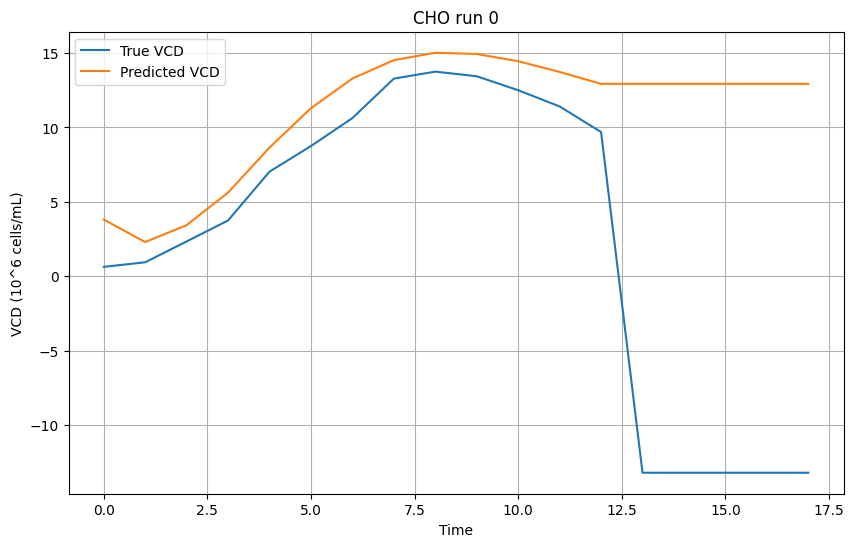

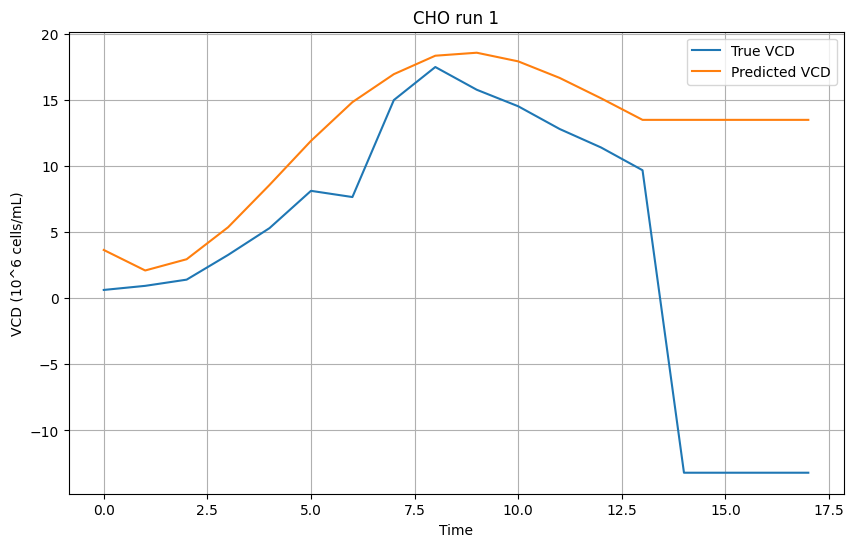

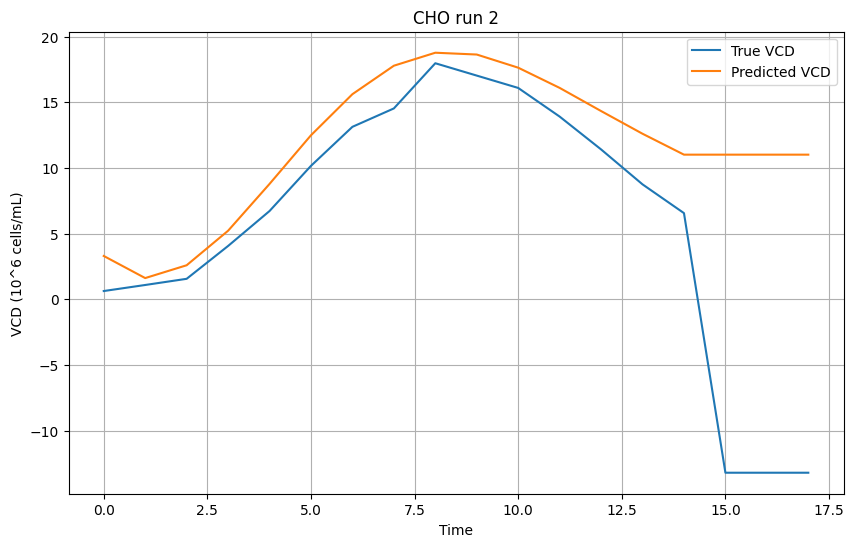

In [ ]:
for i in range(min(3, n_samples)):
    plt.figure(figsize=(10, 6))
    plt.plot(vcd_true_original[i], label='True VCD')
    plt.plot(vcd_pred_original[i], label='Predicted VCD')
    plt.title(f'CHO run {i}')
    plt.xlabel('Time')
    plt.ylabel('VCD (10^6 cells/mL)')
    plt.legend()
    plt.grid(True)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mask = y_test != -2.0

masked_true = vcd_true_original[mask]
masked_pred = vcd_pred_original[mask]

mse = mean_squared_error(masked_true, masked_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(masked_true, masked_pred)

print(f"Test RMSE= {rmse:.2f} 10^6 cells/mL")
print(f"Test MAE= {mae:.2f} 10^6 cells/mL")


Test RMSE= 4.32 10^6 cells/mL
Test MAE= 3.32 10^6 cells/mL


In [ ]:
rmse_p = (rmse / vcd_true_original.max()) * 100
mae_p = (mae / vcd_true_original.max()) * 100

print(f"RMSE = {rmse_p:.1f}% of the VCD max in test set.")
print(f"MAE = {mae_p:.1f}% of the VCD max in test set.")

RMSE = 17.3% of the VCD max in test set.
MAE = 13.3% of the VCD max in test set.


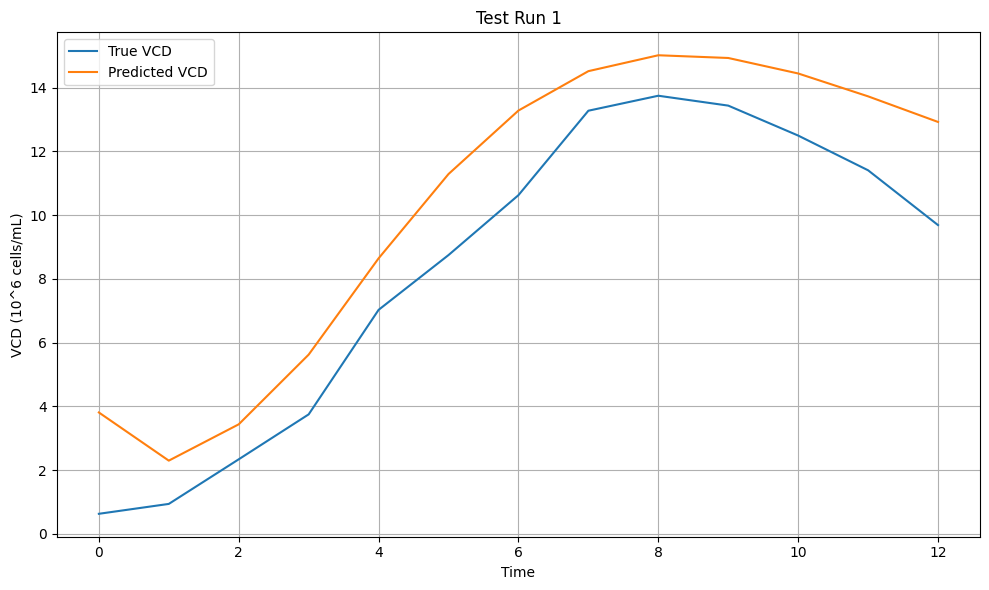

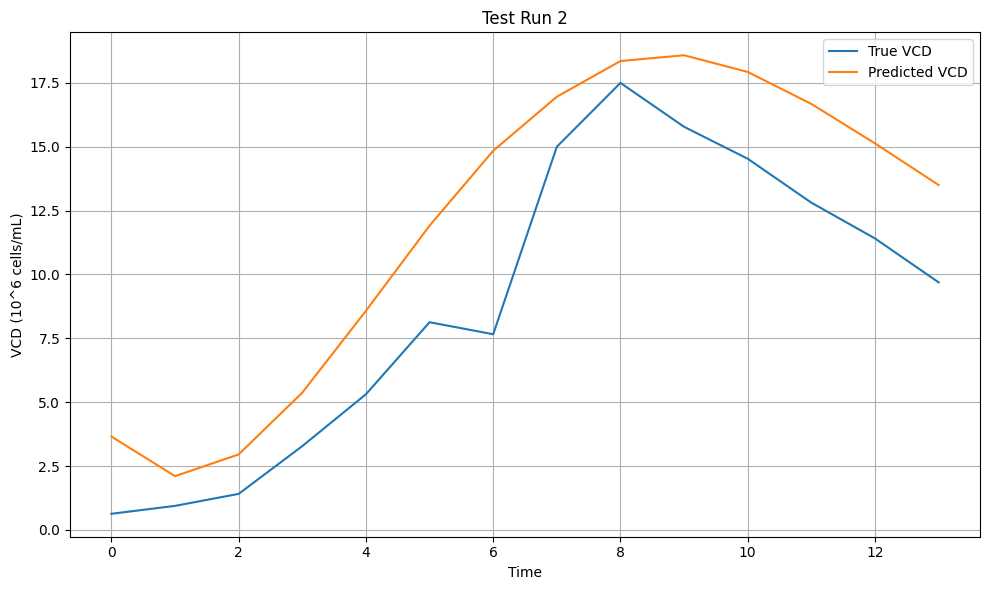

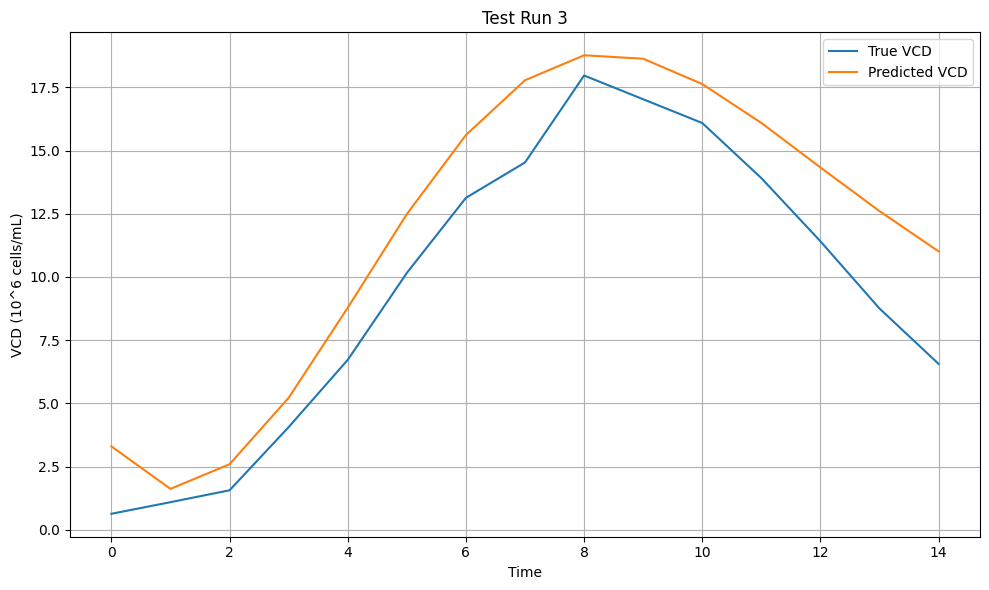

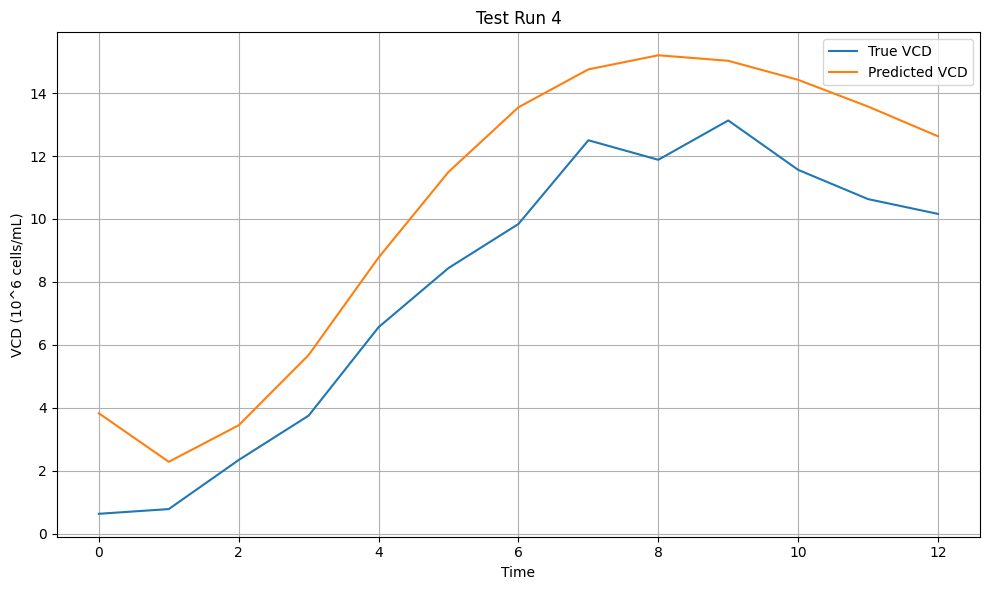

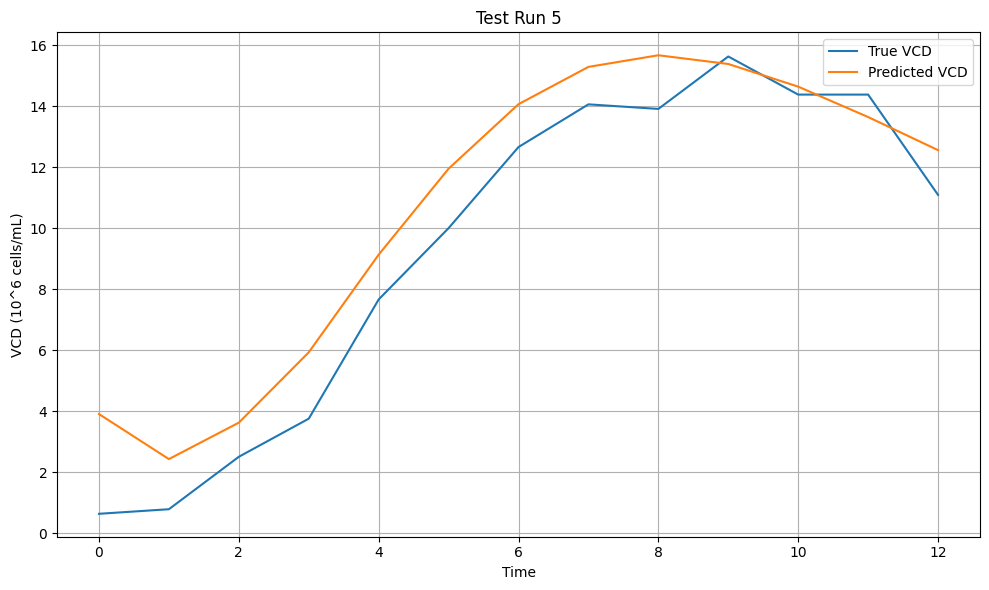

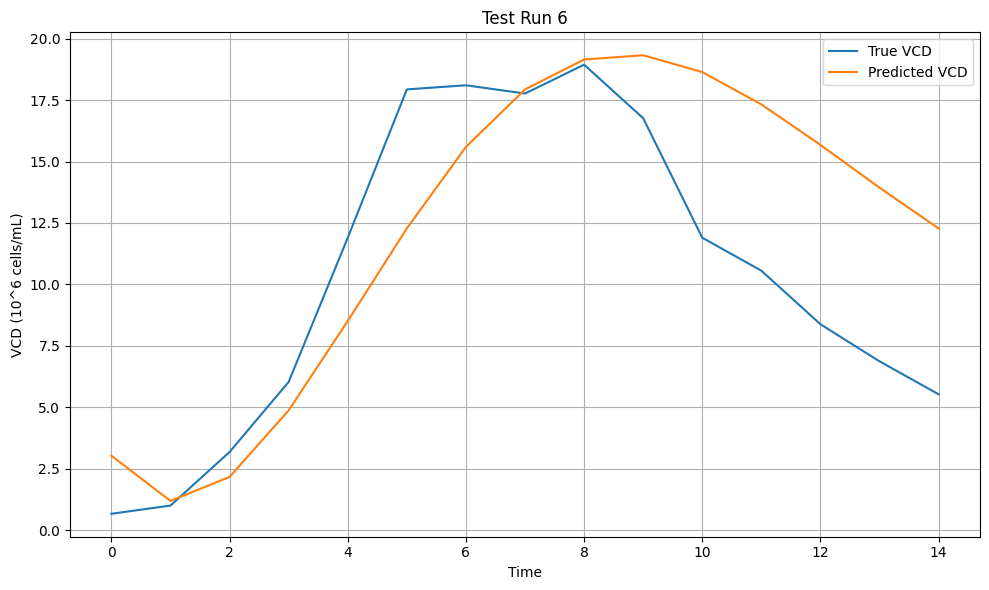

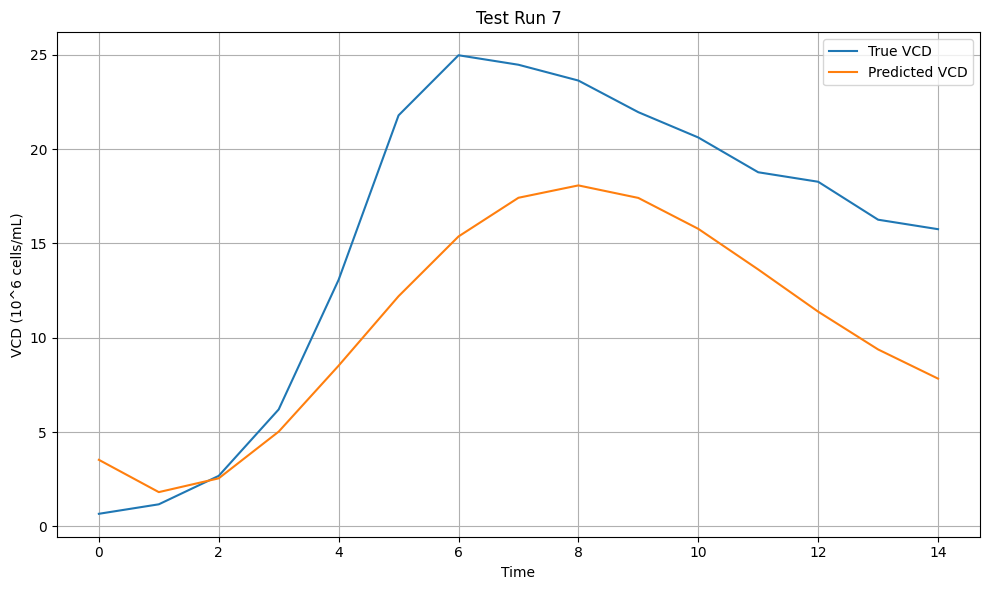

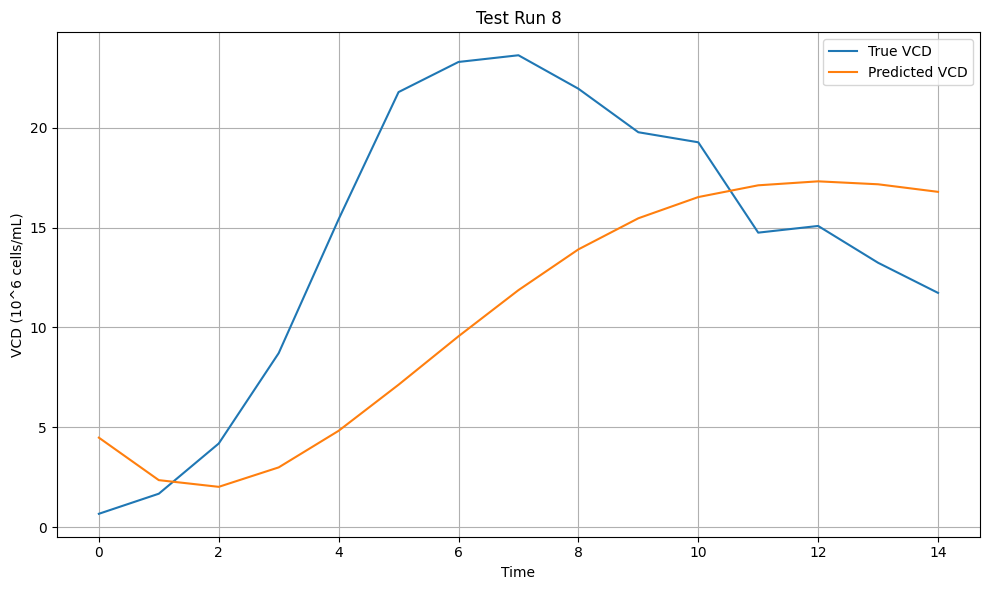

In [ ]:
for i in range(n_samples):
    mask = y_test[i] != -2.0
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(sum(mask)), vcd_true_original[i][mask], label='True VCD')
    plt.plot(np.arange(sum(mask)), vcd_pred_original[i][mask], label='Predicted VCD')
    plt.title(f'Test Run {i+1}')
    plt.xlabel('Time')
    plt.ylabel('VCD (10^6 cells/mL)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

In [ ]:
print("Model predictions at t=0 (scaled):")
print(predicted_vcd[:, 0])

Model predictions at t=0 (scaled):
[-0.73910594 -0.7505303  -0.7770063  -0.73809326 -0.7322918  -0.796717
 -0.7597518  -0.68919766]


In [ ]:
print("True VCD at t=0 (scaled):")
print(y_test[:, 0])

True VCD at t=0 (scaled):
[-0.9747987  -0.9747987  -0.9747987  -0.9747987  -0.9747987  -0.97180486
 -0.97180486 -0.97180486]


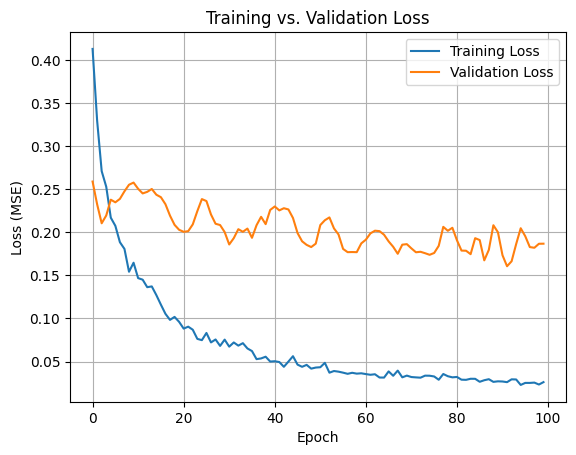

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)